<a href="https://colab.research.google.com/github/anix07/PYTHON-FOR-DATA-ANALYSIS/blob/main/Mathematical_Modelling_for_Urban_traffic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
A = np.array([[2,-1,1,0],[1,1,0,1],[-1,0,3,-1],[0,1,1,1]])
b = np.array([150, 420, 100, 380])
x = np.linalg.solve(A, b)
print(f"det={np.linalg.det(A):.0f}, rank={np.linalg.matrix_rank(A)}")
for i,v in enumerate(x): print(f"x{i+1}={v:.4f}")
print(f"Residual: {A@x-b}")

det=6, rank=4
x1=138.3333
x2=225.0000
x3=98.3333
x4=56.6667
Residual: [ 0.00000000e+00  0.00000000e+00 -2.84217094e-14  0.00000000e+00]


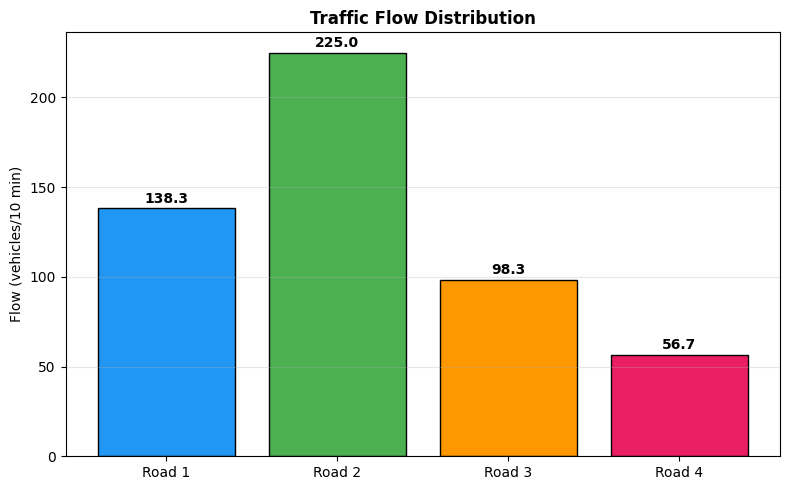

In [3]:
fig,ax = plt.subplots(figsize=(8,5))
ax.bar(['Road 1','Road 2','Road 3','Road 4'], x,
       color=['#2196F3','#4CAF50','#FF9800','#E91E63'], edgecolor='black')
for i,v in enumerate(x): ax.text(i, v+3, f'{v:.1f}', ha='center', fontweight='bold')
ax.set_ylabel('Flow (vehicles/10 min)'); ax.set_title('Traffic Flow Distribution', fontweight='bold')
ax.grid(axis='y',alpha=0.3); plt.tight_layout(); plt.savefig('traffic_flow.png',dpi=150); plt.show()

v:[56.06,83.94] km/h | a:[-1.7890,3.4906] m/s²


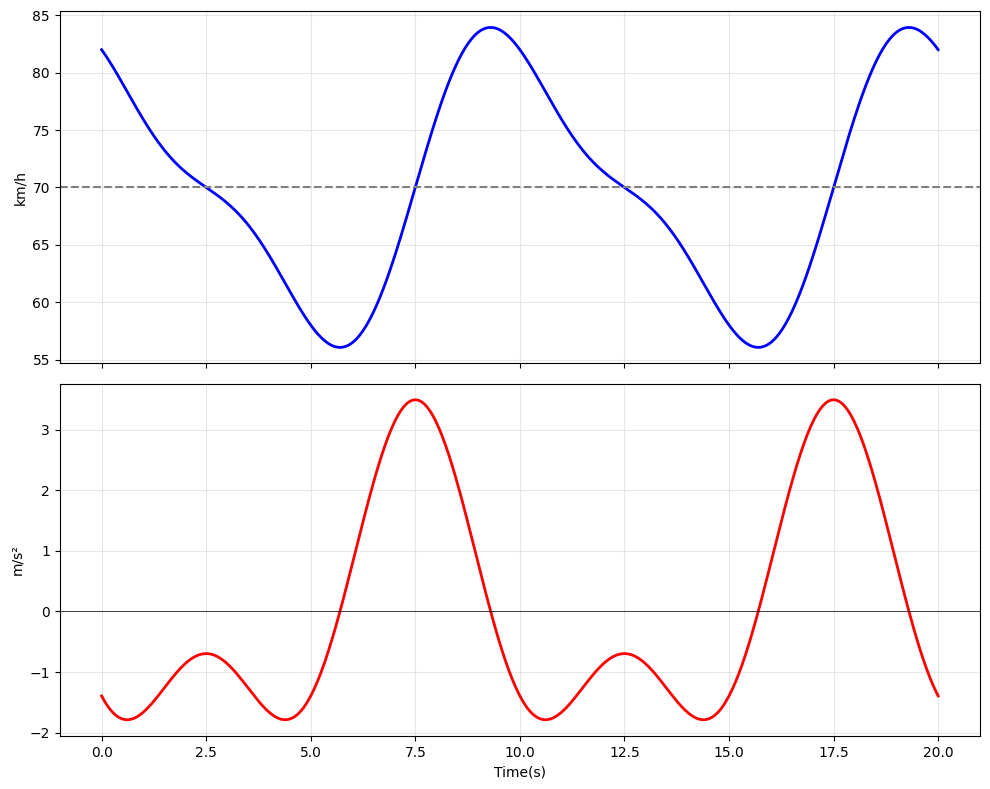

In [4]:
import numpy as np; from scipy.optimize import brentq; import matplotlib.pyplot as plt
t = np.linspace(0,20,500)
v = 70+12*np.cos(np.pi*t/5)-4*np.sin(2*np.pi*t/5)
a = (-12*(np.pi/5)*np.sin(np.pi*t/5)-4*(2*np.pi/5)*np.cos(2*np.pi*t/5))*(1000/3600)
print(f"v:[{v.min():.2f},{v.max():.2f}] km/h | a:[{a.min():.4f},{a.max():.4f}] m/s²")
af=lambda tv:-12*(np.pi/5)*np.sin(np.pi*tv/5)-4*(2*np.pi/5)*np.cos(2*np.pi*tv/5)
fig,(a1,a2)=plt.subplots(2,1,figsize=(10,8),sharex=True)
a1.plot(t,v,'b-',lw=2);a1.axhline(70,color='gray',ls='--');a1.set_ylabel('km/h');a1.grid(alpha=0.3)
a2.plot(t,a,'r-',lw=2);a2.axhline(0,color='black',lw=0.5);a2.set_ylabel('m/s²');a2.set_xlabel('Time(s)')
a2.grid(alpha=0.3);plt.tight_layout();plt.savefig('vel_acc.png',dpi=150);plt.show()

P(R<0.5): z=-1.40, p=0.080757
P(R>1.0): z=0.60, p=0.274253
P(R>1.5): z=2.60, p=0.004661
5th: 0.4388s
25th: 0.6814s
50th: 0.8500s
75th: 1.0186s
95th: 1.2612s
99th: 1.4316s


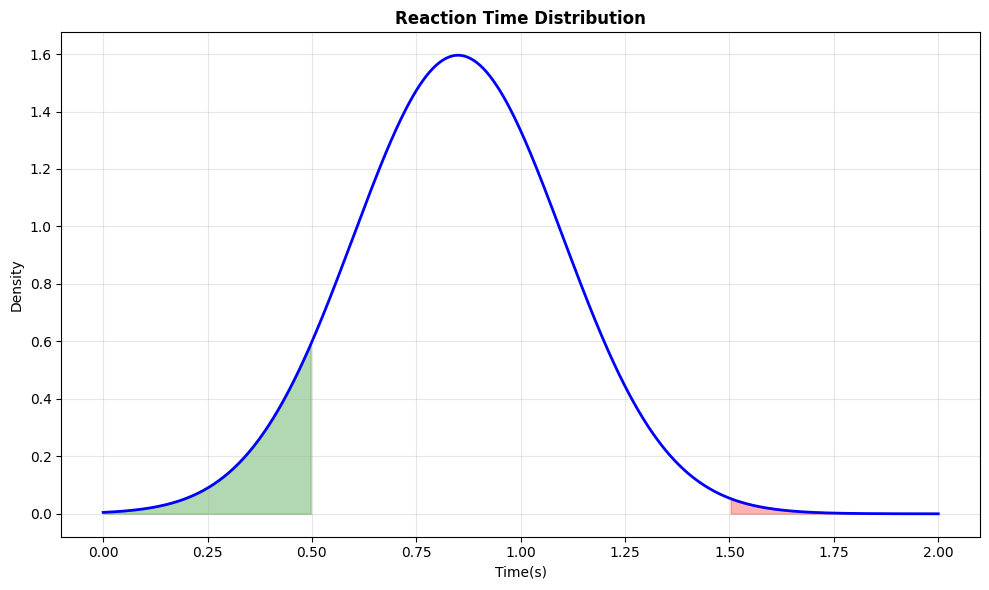

In [5]:
from scipy import stats; import numpy as np; import matplotlib.pyplot as plt
mu,sig=0.85,0.25
for x,l in [(0.5,'<0.5'),(1.0,'>1.0'),(1.5,'>1.5')]:
    z=(x-mu)/sig; p=stats.norm.cdf(x,mu,sig)
    print(f"P(R{l}): z={z:.2f}, p={p if '<' in l else 1-p:.6f}")
for p in [5,25,50,75,95,99]: print(f"{p}th: {stats.norm.ppf(p/100,mu,sig):.4f}s")
x=np.linspace(0,2,500);fig,ax=plt.subplots(figsize=(10,6))
ax.plot(x,stats.norm.pdf(x,mu,sig),'b-',lw=2)
ax.fill_between(x,stats.norm.pdf(x,mu,sig),where=x<0.5,alpha=0.3,color='green')
ax.fill_between(x,stats.norm.pdf(x,mu,sig),where=x>1.5,alpha=0.3,color='red')
ax.set_xlabel('Time(s)');ax.set_ylabel('Density');ax.set_title('Reaction Time Distribution',fontweight='bold')
ax.grid(alpha=0.3);plt.tight_layout();plt.savefig('react.png',dpi=150);plt.show()

Mean=52.1667,Std=2.9181,SE=0.8424,t=2.5721,p=0.012977
95%CI=[50.3126,54.0207]


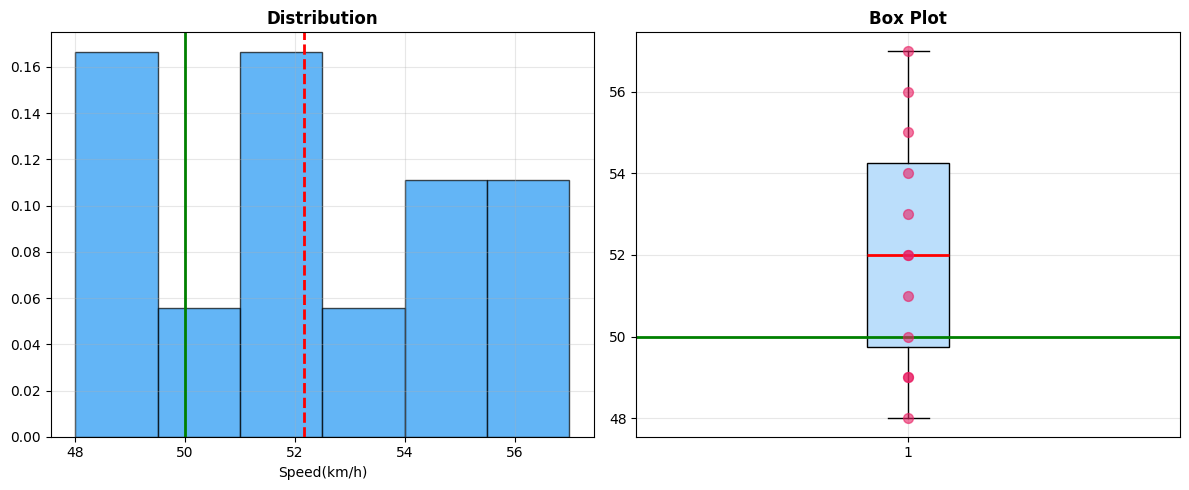

In [6]:
import numpy as np; from scipy import stats; import matplotlib.pyplot as plt
sp=np.array([49,52,55,48,50,53,57,51,54,49,52,56]); n=len(sp)
xb,s,se=np.mean(sp),np.std(sp,ddof=1),np.std(sp,ddof=1)/np.sqrt(n)
t=(xb-50)/se; p=1-stats.t.cdf(t,n-1); tc=stats.t.ppf(0.975,n-1)
print(f"Mean={xb:.4f},Std={s:.4f},SE={se:.4f},t={t:.4f},p={p:.6f}")
print(f"95%CI=[{xb-tc*se:.4f},{xb+tc*se:.4f}]")
fig,(a1,a2)=plt.subplots(1,2,figsize=(12,5))
a1.hist(sp,bins=6,color='#2196F3',edgecolor='black',alpha=0.7,density=True)
a1.axvline(xb,color='red',ls='--',lw=2);a1.axvline(50,color='green',lw=2)
a1.set_xlabel('Speed(km/h)');a1.set_title('Distribution',fontweight='bold');a1.grid(alpha=0.3)
a2.boxplot(sp,patch_artist=True,boxprops=dict(facecolor='#BBDEFB'),medianprops=dict(color='red',lw=2))
a2.axhline(50,color='green',lw=2);a2.scatter([1]*n,sp,color='#E91E63',zorder=5,alpha=0.6,s=50)
a2.set_title('Box Plot',fontweight='bold');a2.grid(alpha=0.3)
plt.tight_layout();plt.savefig('speed.png',dpi=150);plt.show()